# Ejercicio 6: Parquet frente a tablas DuckDB

Este notebook analiza los resultados del benchmark. Las mediciones las produce `scripts/benchmark.py`, que materializa las tablas en `data/processed/taxis.duckdb` y escribe:

- `docs/ejercicio6_materializacion.csv`: tiempo de creacion y tamanio de cada tabla;
- `docs/ejercicio6_benchmark.csv`: tiempos de cada consulta por escala y estrategia.

Para repetir las mediciones: `docker compose exec lab python scripts/benchmark.py` (unos 15 minutos). La interpretacion esta en `docs/ejercicio6.md`.

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

pd.set_option("display.max_columns", None)
ESCALAS = ["1 mes (2026-01)", "2026 (8 meses)", "todos los anios"]
COLORES = {"parquet": "#2a78d6", "tabla": "#eb6834"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "lines.linewidth": 2, "figure.dpi": 110,
})

mat = pd.read_csv("docs/ejercicio6_materializacion.csv")
bench = pd.read_csv("docs/ejercicio6_benchmark.csv")
bench["escala"] = pd.Categorical(bench["escala"], ESCALAS, ordered=True)

## 6.2 Tabla materializada

Tablas presentes en `data/processed/taxis.duckdb` (abierta en solo lectura):

In [2]:
con = duckdb.connect("data/processed/taxis.duckdb", read_only=True)
con.sql("""
    SELECT table_name AS tabla, estimated_size AS filas, column_count AS columnas
    FROM duckdb_tables() ORDER BY estimated_size
""").df()

,tabla,filas,columnas
0,zonas,265,4
1,viajes_2026_01,3765161,24
2,viajes_2026,30040469,25
3,viajes,71870407,25


In [3]:
con.sql("DESCRIBE viajes").df()

,column_name,column_type,null,key,default,extra
0,tipo,VARCHAR,YES,None,None,None
1,mes_archivo,VARCHAR,YES,None,None,None
2,pickup,TIMESTAMP,YES,None,None,None
3,dropoff,TIMESTAMP,YES,None,None,None
4,VendorID,INTEGER,YES,None,None,None
5,passenger_count,BIGINT,YES,None,None,None
6,trip_distance,DOUBLE,YES,None,None,None
7,RatecodeID,BIGINT,YES,None,None,None
8,store_and_fwd_flag,VARCHAR,YES,None,None,None
9,PULocationID,INTEGER,YES,None,None,None


In [4]:
con.close()

### Costo de materializar cada escala

In [5]:
mat.assign(tabla_vs_parquet=(mat.mib_tabla_duckdb / mat.mib_parquet).round(2),
           filas_por_segundo=(mat.filas / mat.segundos_creacion).round(0))

,escala,tabla,filas,segundos_creacion,mib_parquet,mib_tabla_duckdb,tabla_vs_parquet,filas_por_segundo
0,1 mes (2026-01),viajes_2026_01,3765161,4.34,62.1,102.0,1.64,867549.0
1,2026 (8 meses),viajes_2026,30040469,33.64,495.7,815.5,1.65,892998.0
2,todos los anios,viajes,71870407,81.35,1171.7,1934.2,1.65,883472.0


## 6.5 y 6.7 Tiempos de ejecucion

Mediana de las ejecuciones repetidas (en segundos) y aceleracion de la tabla frente a Parquet (`parquet / tabla`). Todas las consultas devolvieron el mismo resultado con ambas estrategias:

In [6]:
print("resultados identicos en todas las combinaciones:", bench.resultado_igual.all())

resultados identicos en todas las combinaciones: True


In [7]:
mediana = bench.pivot_table(index="consulta", columns=["escala", "estrategia"], values="mediana_s", observed=True)
aceleracion = (mediana.xs("parquet", axis=1, level="estrategia")
               / mediana.xs("tabla", axis=1, level="estrategia")).round(1)
display(mediana.round(3))
display(aceleracion.add_suffix(" (x)"))

escala                 1 mes (2026-01)        2026 (8 meses)         \
estrategia                     parquet  tabla        parquet  tabla   
consulta                                                              
b1_volumen_mensual               0.534  0.157          2.204  1.487   
b2_hora_dia_semana               0.295  0.067          1.047  0.454   
b3_percentiles                   0.678  0.647          5.925  5.949   
b4_top_zonas                     0.203  0.086          0.976  0.414   
b5_filtro_selectivo              0.161  0.007          0.414  0.008   
b6_consistencia_montos           0.362  0.190          2.332  1.013   

escala                 todos los anios          
estrategia                     parquet   tabla  
consulta                                        
b1_volumen_mensual               4.928   3.026  
b2_hora_dia_semana               2.648   0.890  
b3_percentiles                  15.643  16.203  
b4_top_zonas                     2.529   1.102  
b5_filtro_selectivo              1.006   0.008  
b6_consistencia_montos           4.912   2.382

escala,1 mes (2026-01) (x),2026 (8 meses) (x),todos los anios (x)
consulta,,,
b1_volumen_mensual,3.4,1.5,1.6
b2_hora_dia_semana,4.4,2.3,3.0
b3_percentiles,1.0,1.0,1.0
b4_top_zonas,2.4,2.4,2.3
b5_filtro_selectivo,22.3,53.1,119.7
b6_consistencia_montos,1.9,2.3,2.1


### Primera ejecucion frente a ejecuciones repetidas (escala completa)

In [8]:
completa = bench[bench.escala == "todos los anios"]
completa.pivot_table(index="consulta", columns="estrategia",
                     values=["primera_s", "mediana_s", "min_s", "max_s"], observed=True).round(3)

max_s         mediana_s           min_s          \
estrategia             parquet   tabla   parquet   tabla parquet   tabla   
consulta                                                                   
b1_volumen_mensual       5.122   3.358     4.928   3.026   4.380   2.702   
b2_hora_dia_semana       2.722   0.972     2.648   0.890   2.422   0.854   
b3_percentiles          16.238  17.521    15.643  16.203  13.832  14.869   
b4_top_zonas             2.995   1.330     2.529   1.102   2.236   0.972   
b5_filtro_selectivo      1.298   0.010     1.006   0.008   0.974   0.007   
b6_consistencia_montos   5.335   3.031     4.912   2.382   4.687   2.130   

                       primera_s          
estrategia               parquet   tabla  
consulta                                  
b1_volumen_mensual         4.672   4.402  
b2_hora_dia_semana         2.438   1.651  
b3_percentiles            16.749  16.696  
b4_top_zonas               2.664   1.736  
b5_filtro_selectivo        1.003   0.075  
b6_consistencia_montos     5.534   5.953

## 6.6 Comportamiento segun la cantidad de datos

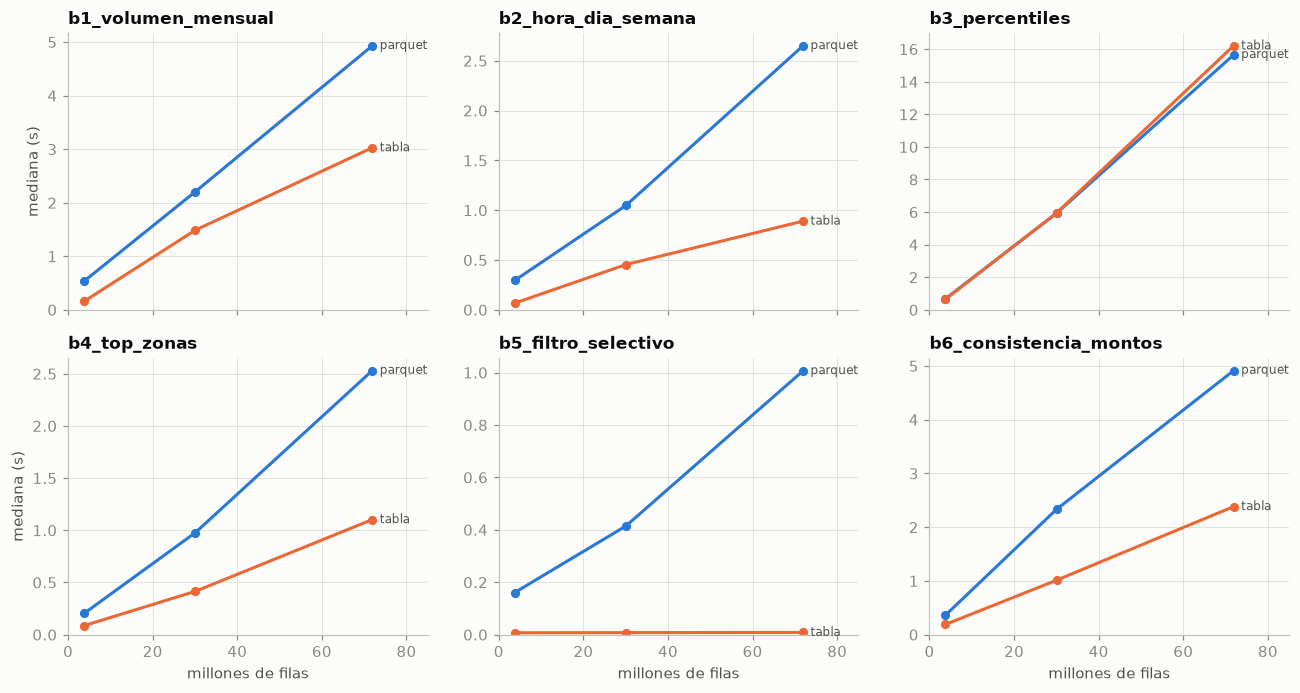

In [9]:
filas = mat.set_index("escala").filas
bench["filas"] = bench.escala.astype(str).map(filas)
consultas = sorted(bench.consulta.unique())
fig, axes = plt.subplots(2, 3, figsize=(12, 6.4), sharex=True)
for ax, consulta in zip(axes.flat, consultas):
    d = bench[bench.consulta == consulta]
    for estrategia, g in d.groupby("estrategia"):
        g = g.sort_values("filas")
        ax.plot(g.filas / 1e6, g.mediana_s, color=COLORES[estrategia], marker="o", markersize=5)
        ax.annotate(estrategia, (g.filas.iloc[-1] / 1e6, g.mediana_s.iloc[-1]), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8, color="#52514e")
    ax.set_title(consulta)
    ax.set_ylim(bottom=0)
    ax.set_xlim(0, 85)
for ax in axes[1]:
    ax.set_xlabel("millones de filas")
for ax in axes[:, 0]:
    ax.set_ylabel("mediana (s)")
plt.tight_layout()

In [10]:
# Segundos por cada millon de filas: cuanto cuesta procesar cada millon segun la escala
(bench.assign(s_por_millon=bench.mediana_s / (bench.filas / 1e6))
      .pivot_table(index="consulta", columns=["estrategia", "escala"], values="s_por_millon", observed=True)
      .round(3))

estrategia                     parquet                                 \
escala                 1 mes (2026-01) 2026 (8 meses) todos los anios   
consulta                                                                
b1_volumen_mensual               0.142          0.073           0.069   
b2_hora_dia_semana               0.078          0.035           0.037   
b3_percentiles                   0.180          0.197           0.218   
b4_top_zonas                     0.054          0.032           0.035   
b5_filtro_selectivo              0.043          0.014           0.014   
b6_consistencia_montos           0.096          0.078           0.068   

estrategia                       tabla                                 
escala                 1 mes (2026-01) 2026 (8 meses) todos los anios  
consulta                                                               
b1_volumen_mensual               0.042          0.049           0.042  
b2_hora_dia_semana               0.018          0.015           0.012  
b3_percentiles                   0.172          0.198           0.225  
b4_top_zonas                     0.023          0.014           0.015  
b5_filtro_selectivo              0.002          0.000           0.000  
b6_consistencia_montos           0.050          0.034           0.033